# Attention Seq2seqによる日付変換

## 目的
日付変換，つまり(曜日，日付，年数)を(年数-月-日)に変換させるタスクを通じて，Attention Seq2seqの構造を理解する．

## Attention機構
Seq2Seqはエンコーダが長期のパターンを学習する際に直近の情報に強く影響されるため，過去の特徴をうまく捉えることが難しいとされています．そこで，各時刻のエンコーダの出力を保持し，デコーダ側へ情報を伝搬するAttention機構を導入することで，この問題を解決します．Attention機構は保持したエンコーダの出力をデコーダの出力に対して重みづけすることで，どの時刻のエンコーダに着目してデコーダが文字等の情報を生成したかを可視化することもできます．

## 参考文献
本ノートブックの実装は，以下のサイトを参考にしています．\
https://qiita.com/m__k/items/646044788c5f94eadc8d

## モジュールのインポート

はじめに必要なモジュールをインポートしたのち，GPUを使用した計算が可能かどうかを確認する．

In [39]:
import os
from time import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import gdown

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## データ準備
日付変換をするために，[0から作るDeep Learning 2](https://github.com/oreilly-japan/deep-learning-from-scratch-2)のGitHubからデータ（`date.txt`）を使用します．`date.txt`には50000サンプルが含まれており，先頭40000サンプルを学習用，残り10000サンプルを評価用として`DateDataset`（PyTorchの`Dataset`クラス）にまとめます．

In [2]:
if not os.path.isfile('date.txt'):
    gdown.download(id='1so-mITQ37mdMCTFfZiX2tBGsfZnthuTF', output='date.txt', quiet=False)

input_date = [] # 変換前の日付データ
output_date = [] # 変換後の日付データ

# date.txtを1行ずつ読み込んで変換前と変換後に分割して、inputとoutputで分ける
with open("./date.txt", "r") as f:
  date_list = f.readlines()
  for date in date_list:
    date = date[:-1]
    input_date.append(date.split("_")[0])
    output_date.append("_" + date.split("_")[1])

# inputとoutputの系列の長さを取得
# すべて長さが同じなので、0番目の要素でlenを取ってます
input_len = len(input_date[0]) # 29
output_len = len(output_date[0]) # 11

# date.txtで登場するすべての文字にIDを割り当てる
char2id = {}
for input_chars, output_chars in zip(input_date, output_date):
  for c in input_chars:
    if not c in char2id:
      char2id[c] = len(char2id)
  for c in output_chars:
    if not c in char2id:
      char2id[c] = len(char2id)

# ID→文字列に変換するための辞書（評価・可視化で使用）
id2char = {v: k for k, v in char2id.items()}

input_data = [] # ID化された変換前日付データ
output_data = [] # ID化された変換後日付データ
for input_chars, output_chars in zip(input_date, output_date):
  output_ids = [char2id[c] for c in output_chars]
  if len(output_ids) != output_len:
    # ごく一部，出力の文字数が足りない行があるため，0で埋めて長さを揃える
    output_ids += [0] * (output_len - len(output_ids))
  output_data.append(output_ids)
  input_data.append([char2id[c] for c in input_chars])

vocab_size = len(char2id)


class DateDataset(torch.utils.data.Dataset):
    def __init__(self, input_data, output_data):
        super().__init__()
        self.input_data = np.asarray(input_data)
        self.output_data = np.asarray(output_data)

    def __getitem__(self, item):
        return self.input_data[item], self.output_data[item]

    def __len__(self):
        return self.input_data.shape[0]


# 全50000サンプルのうち，先頭40000サンプルを学習用，残り10000サンプルを評価用に分割する
train_dataset = DateDataset(input_data[:40000], output_data[:40000])
test_dataset = DateDataset(input_data[40000:], output_data[40000:])

Downloading...
From: https://drive.google.com/uc?id=1so-mITQ37mdMCTFfZiX2tBGsfZnthuTF
To: /workspace/13_rnn/date.txt
100%|█████████████████████████████████████████████████████████████████████████████| 2.10M/2.10M [00:00<00:00, 10.3MB/s]


## エンコーダ・デコーダの作成
基本的な構造は`attention_calc.ipynb`のエンコーダ・デコーダ構造と同様です．ただし，エンコーダは各時刻の出力値（`encoder_outputs`）を保持しておきます．デコーダでは，保持したエンコーダの出力値とデコーダの出力値で内積計算します．この内積計算によって，各時刻のエンコーダの出力値に重み付けすることができます．これにより，どの時刻のエンコーダの出力に着目したかをデコーダ側が自動で決定することができます．

入力日付文字列は空白（` `）で29文字の固定長に揃えていますが，末尾の空白は本来意味を持たない時刻です．そこで，エンコーダでは`pack_padded_sequence`を使って空白の時刻をLSTMの計算対象から除外し，デコーダのAttentionスコア計算でも空白に対応する位置のスコアを`-inf`にしてから`softmax`を取ることで，空白の位置にAttentionの重みが乗らないようにしています．

In [3]:
# Encoderクラス
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=char2id[" "])
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, input_indices):
        embedding = self.word_embeddings(input_indices)

        # 末尾の空白を除いた実際の系列長を求め，pack_padded_sequenceでLSTMに空白の時刻を計算させないようにする
        input_lengths = (input_indices != char2id[" "]).sum(dim=1).clamp(min=1).cpu()
        packed_embedding = nn.utils.rnn.pack_padded_sequence(
            embedding, input_lengths, batch_first=True, enforce_sorted=False
        )
        packed_outputs, state = self.lstm(packed_embedding)
        # 元の系列長（input_indices.size(1)）に合わせてゼロ埋めで復元する
        encoder_outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs, batch_first=True, total_length=input_indices.size(1)
        )

        return encoder_outputs, state, input_lengths

# Attention Decoderクラス
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=char2id[" "])
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        # hidden_dim*2としているのは、各時刻のLSTMの隠れ層とAttention層で計算したコンテキストベクトルをtorch.catでつなぎ合わせることで長さが２倍になるため
        self.output = nn.Linear(hidden_dim * 2, vocab_size)
        # 列方向を確率変換したいのでdim=1
        self.softmax = nn.Softmax(dim=1)

    def forward(self, decoder_input, encoder_outputs, state, input_lengths):
        embedding = self.word_embeddings(decoder_input)
        decoder_outputs, state = self.lstm(embedding, state)

        # エンコーダの各時刻の出力とデコーダの各時刻の出力の内積からattention scoreを求める
        attention_score = torch.bmm(encoder_outputs, decoder_outputs.transpose(1, 2))

        # 空白（パディング）の位置のscoreを-infにして，softmax後の重みがほぼ0になるようにする
        input_len = encoder_outputs.size(1)
        pad_positions = torch.arange(input_len, device=encoder_outputs.device)[None, :] >= input_lengths[:, None].to(encoder_outputs.device)
        attention_score = attention_score.masked_fill(pad_positions.unsqueeze(2), float("-inf"))

        attention_weight = self.softmax(attention_score)

        # 各デコーダ時刻について，attention weightで重み付けしたエンコーダ出力（コンテキストベクトル）をまとめて計算する
        context_vector = torch.bmm(attention_weight.transpose(1, 2), encoder_outputs)

        output = torch.cat([decoder_outputs, context_vector], dim=2)
        output = self.output(output)
        return output, state, attention_weight

## モデル定義，損失関数，最適化手法
EncoderとAttentionDecoderに各パラメータを引数として入れます．損失関数にはCrossEntropyLossを用います．pytorchのCrossEntropyLossには内部にSoftmax関数を持つため，ネットワークの出力後にSoftmax関数を割り当てる必要はありません．最適化手法にはAdamを使用します．

In [37]:
embedding_dim = 128
hidden_dim = 256
vocab_size = len(char2id)

encoder = Encoder(vocab_size, embedding_dim, hidden_dim).to(device)
attn_decoder = AttentionDecoder(vocab_size, embedding_dim, hidden_dim).to(device)

# 損失関数
criterion = nn.CrossEntropyLoss().to(device)

# 最適化
learning_rate = 0.001
encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
attn_decoder_optimizer = optim.Adam(attn_decoder.parameters(), lr=learning_rate)

## 学習
学習を行います．学習データの準備や誤差計算の基本的な流れは`attention_calc.ipynb`と同様です．

In [ ]:
batch_size = 100
epoch_num = 1000

# データローダの準備
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# ネットワークを学習モードへ変更
encoder.train()
attn_decoder.train()

start = time()
for epoch in range(1, epoch_num+1):
    sum_loss = 0.0

    for input_tensor, output_tensor in train_loader:
        input_tensor = input_tensor.to(device)
        output_tensor = output_tensor.to(device)

        # 勾配の初期化
        encoder_optimizer.zero_grad()
        attn_decoder_optimizer.zero_grad()

        # Encoderの順伝搬
        encoder_outputs, encoder_state, input_lengths = encoder(input_tensor)

        # Attention Decoderのインプット
        source = output_tensor[:, :-1]

        # Attention Decoderの正解データ
        target = output_tensor[:, 1:]

        loss = 0
        decoder_output, _, attention_weight = attn_decoder(source, encoder_outputs, encoder_state, input_lengths)
        for j in range(decoder_output.size(1)):
            loss += criterion(decoder_output[:, j, :], target[:, j])

        sum_loss += loss.item()

        # 誤差逆伝播
        loss.backward()

        # パラメータ更新
        encoder_optimizer.step()
        attn_decoder_optimizer.step()

    elapsed_time = time() - start
    if epoch % 10 == 0:
        print("epoch: {}, mean loss: {:.4f}, elapsed_time: {:.4f}".format(epoch, sum_loss / len(train_loader), elapsed_time))

    # 100 epochに1回ネットワークモデルのパラメータを保存
    if epoch % 100 == 0:
        model_name = "attention_date_v{}.pt".format(epoch)
        torch.save({
            'encoder_model': encoder.state_dict(),
            'decoder_model': attn_decoder.state_dict(),
        }, model_name)

## 評価
表は入力，教師，デコーダの予測出力，正答率を表します．評価には，実際にモデルを使って日付変換の結果を得る場面を反映した「自己回帰的な複数ステップ先予測」を用います．

### GPUが使用できず，学習ができなかった場合

学習済みモデルを用意していますので，下記のコマンドを実行してファイルをダウンロードしてください．

In [ ]:
# データのダウンロード
if not os.path.isfile('attention_date_v1000.pt'):
    gdown.download(id='1ZtbrVl1i1-lG27wZTPGouDW4ULZObUyB', output='attention_date_v1000.pt', quiet=False)

エンコーダ・デコーダはバッチサイズを固定せず，入力テンソルから毎回バッチサイズを求める実装になっているため，学習時と評価時で同じクラスをそのまま使えます．

ここでは，学習済みパラメータを読み込むために，エンコーダとデコーダを新たに生成します．

In [45]:
encoder = Encoder(vocab_size, embedding_dim, hidden_dim).to(device)
attn_decoder = AttentionDecoder(vocab_size, embedding_dim, hidden_dim).to(device)

model_name = "attention_date_v{}.pt".format(1000)
checkpoint = torch.load(model_name, map_location=device)
encoder.load_state_dict(checkpoint["encoder_model"])
attn_decoder.load_state_dict(checkpoint["decoder_model"])

encoder.eval()
attn_decoder.eval()

AttentionDecoder(
  (word_embeddings): Embedding(59, 128, padding_idx=7)
  (lstm): LSTM(128, 256, batch_first=True)
  (output): Linear(in_features=512, out_features=59, bias=True)
  (softmax): Softmax(dim=1)
)

### 自己回帰的な複数ステップ先予測
実際に日付を変換する場面では正解ラベルは手元にないため，デコーダは自分自身が予測した文字を次時刻の入力として使い回しながら，変換後の文字列を1文字ずつ生成していく必要があります．ここでは，開始記号`_`から始めて，デコーダ自身の予測結果を次時刻の入力として繰り返し与え，`output_len - 1`文字分の生成を続けます．これが，実際にモデルを使って日付変換の結果を得る場面を反映した，より現実的な評価です．なお，このとき各時刻のattention weightも保持しておき，後の可視化にそのまま利用します．

In [48]:
# Decoderのアウトプットのテンソルから要素が最大のインデックスを返す。つまり生成文字を意味します
def get_max_index(decoder_output):
  # decoder_output: [batch, 1, vocab_size] -> 各サンプルの最大スコアのインデックスを [batch, 1] で返す
  return torch.argmax(decoder_output.squeeze(1), dim=1, keepdim=True)

# 評価用データ
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

test_inputs = []   # 表示用に，評価に使った入力をバッチごとに保持しておく
test_targets = []  # 表示用に，評価に使った正解ラベルをバッチごとに保持しておく
predicts = []
attention_weights = []  # 可視化用に，自己回帰生成時のattention weightも保持しておく

with torch.no_grad():
  for input_tensor, output_tensor in test_loader:
    input_tensor = input_tensor.to(device)
    output_tensor = output_tensor.to(device)

    encoder_outputs, encoder_state, input_lengths = encoder(input_tensor)

    # Decoderにはまず文字列生成開始を表す"_"をインプットにするので、"_"のtensorをバッチサイズ分作成
    start_char_batch = [[char2id["_"]] for _ in range(input_tensor.size(0))]
    decoder_input_tensor = torch.tensor(start_char_batch, device=device)

    decoder_state = encoder_state
    batch_tmp = torch.zeros(input_tensor.size(0), 1, dtype=torch.long, device=device)
    attn_tmp = []
    for _ in range(output_len - 1):
      decoder_output, decoder_state, attention_weight = attn_decoder(decoder_input_tensor, encoder_outputs, decoder_state, input_lengths)
      # 予測文字を取得しつつ、そのまま次のdecoderのインプットとなる（自己回帰）
      decoder_input_tensor = get_max_index(decoder_output)
      batch_tmp = torch.cat([batch_tmp, decoder_input_tensor], dim=1)
      attn_tmp.append(attention_weight)
    test_inputs.append(input_tensor)
    test_targets.append(output_tensor)
    predicts.append(batch_tmp[:,1:])
    attention_weights.append(torch.cat(attn_tmp, dim=2))  # [batch, input_len, output_len-1]

row = []
for i in range(len(test_inputs)):
  batch_input = test_inputs[i]
  batch_output = test_targets[i]
  batch_predict = predicts[i]
  for inp, output, predict in zip(batch_input, batch_output, batch_predict):
    x = [id2char[idx.item()] for idx in inp]
    y = [id2char[idx.item()] for idx in output[1:]]
    p = [id2char[idx.item()] for idx in predict]

    x_str = "".join(x)
    y_str = "".join(y)
    p_str = "".join(p)

    judge = "O" if y_str == p_str else "X"
    row.append([x_str, y_str, p_str, judge])
predict_df = pd.DataFrame(row, columns=["input", "answer", "predict", "judge"])
predict_df.head()

print("Accuracy (autoregressive): {:.4f}".format(len(predict_df.query('judge == "O"')) / len(predict_df)))

Accuracy (autoregressive): 0.3149


予測結果を表示します．

In [50]:
predict_df.head()

,input,answer,predict,judge
0,"THURSDAY, AUGUST 11, 1988",1988-08-11,1979-08-11,X
1,"February 23, 1977",1977-02-23,1983-02-23,X
2,"June 26, 1984",1984-06-26,1985-06-26,X
3,"Sep 17, 1980",1980-09-17,1996-09-17,X
4,"June 13, 2005",2005-06-13,2002-06-13,X


## Attentionの可視化
横軸がEncoderの入力，縦軸が生成文字を表しています．
生成文字を1文字ずつ見たとき，左に並んでいるボックスの色が一番明るいところの文字が一番attentionして生成された文字を表しています．

上の自己回帰的な複数ステップ先予測で保持しておいた`attention_weights`と`predicts`（実際にモデルが生成した文字）をそのまま使って可視化するため，ここで新たにモデルの順伝搬を行う必要はありません．

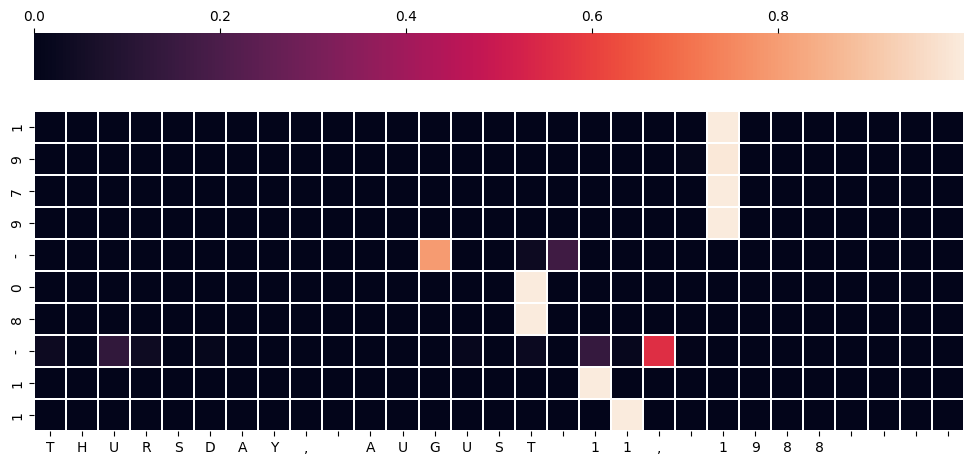

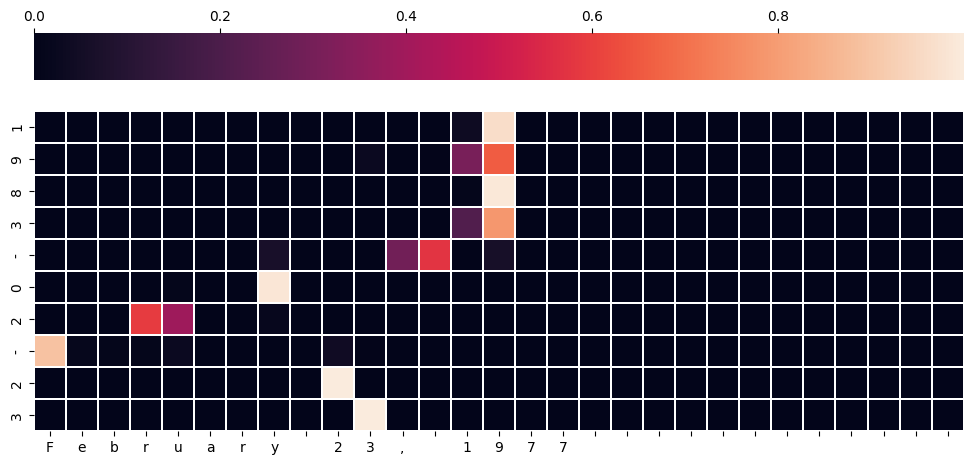

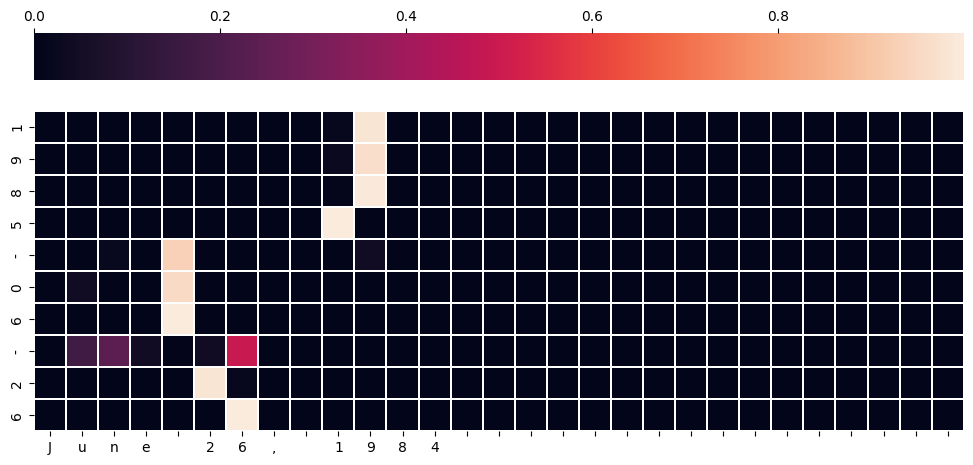

In [51]:
input_minibatch = test_inputs[0]
attn_vis = attention_weights[0]
predict_vis = predicts[0]

for i in range(3):
    p_chars = [id2char[idx.item()] for idx in predict_vis[i]]
    df = pd.DataFrame(data=torch.transpose(attn_vis[i], 0, 1).cpu().numpy(),
                      columns=[id2char[idx.item()] for idx in input_minibatch[i]],
                      index=p_chars)
    plt.figure(figsize=(12, 8))
    sns.heatmap(df, xticklabels = 1, yticklabels = 1, square=True, linewidths=.3, cbar_kws = dict(use_gridspec=False, location="top"))

## 課題

1. 他のリカレントニューラルネットワークを使って精度比較をしてみましょう．
    **ヒント**：その他のネットワークとしては`nn.RNN`や`nn.GRU`があります．
2. 色々なAttentionの可視化から考察してみよう．